In [57]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [58]:
from matplotlib import rcParams
rcParams['font.family'] = 'Arial'
rcParams['pdf.fonttype'] = 42  # Use TrueType fonts
rcParams['axes.linewidth'] = 0.5
rcParams['xtick.major.width'] = 0.5
rcParams['ytick.major.width'] = 0.5
rcParams['savefig.dpi'] = 300  # Ensure a high resolution

In [59]:
from catrace.trial_similarity import compute_population_multitrial_similarity_over_time, plot_matrix_per_condition, SimToTemplateParams, compute_population_multitrial_similarity_over_time_to_template, plot_slicing_per_condition

In [60]:
from catrace.exp_collection import read_df
import matplotlib.pyplot as plt
from catrace.dataset import load_dataset_config

from catrace.trial_similarity import PlotTrialSimilarityParams, PlotTrialSimilarityPerCondParams
def compute_and_plot_trial_similarity_mat(dsconfig, odor, similarity_method, params: PlotTrialSimilarityPerCondParams):
    odor_trials = [(odor, 0), (odor, 1), (odor, 2)]
    simdf = compute_population_multitrial_similarity_over_time(dsconfig, odor_trials, dsconfig.exp_list, bin_size=None, similarity_method=similarity_method)
    fig, axs = plot_matrix_per_condition(simdf, conditions=dsconfig.conditions, frame_range=(18, 93), params=params)
    return fig


def compute_corr_over_time_for_paper(dsconfigs, regions, similarity_method):
    odor = 'Arg'
    odor_trials = [(odor, 0), (odor, 1), (odor, 2)]
    simdf_dict = {}
    for dsconfig, region in zip(dsconfigs, regions):
        simdf = compute_population_multitrial_similarity_over_time(dsconfig, odor_trials, dsconfig.exp_list, bin_size=None, similarity_method=similarity_method)
        simdf_dict[region] = simdf
    return simdf_dict


dp_dsconfig = load_dataset_config('../dataset_configs/juvenile_dataset_t7.json')
ob_dsconfig = load_dataset_config('../dataset_configs/juvenile_dataset_OB_t7.json')
regions = ['Dp', 'OB']
dsconfigs = [dp_dsconfig, ob_dsconfig]
similarity_method='pattern_correlation'
frame_range = (18, 93)

simdf_dict = compute_corr_over_time_for_paper(dsconfigs, regions, similarity_method)



2021-07-15-DpOBEM-N2_Dp None
2021-07-16-DpOBEM-N3_Dp None
2021-12-10-DpOBEM-N4_Dp None
2021-12-31-DpOBEM-N7_Dp None
2022-02-13-DpOBEM-N10_Dp None
2022-02-20-DpOBEM-N11_Dp None
2021-02-05-DpOBEM-JH9_Dp None
2021-03-18-DpOBEM-JH10_Dp None
2021-03-19-DpOBEM-JH10_Dp None
2021-04-02-DpOBEM-JH11_Dp None
2021-04-03-DpOBEM-JH11_Dp None
2021-05-01-DpOBEM-JH13_Dp None
2021-05-22-DpOBEM-JH14_Dp None
2021-09-15-DpOBEM-JH20_Dp None
2021-09-17-DpOBEM-JH20_Dp None
2021-09-18-DpOBEM-JH20_Dp None
2021-07-30-DpOBEM-JH17_Dp None
2021-07-31-DpOBEM-JH17_Dp None
2021-09-02-DpOBEM-JH18_Dp None
2021-09-03-DpOBEM-JH18_Dp None
2021-09-04-DpOBEM-JH18_Dp None
2021-09-29-DpOBEM-JH21_Dp None
2021-10-01-DpOBEM-JH21_Dp None
2021-10-02-DpOBEM-JH21_Dp None
2021-10-14-DpOBEM-JH22_Dp None
2021-11-10-DpOBEM-JH23_Dp None
2021-11-11-DpOBEM-JH23_Dp None
2021-11-14-DpOBEM-JH23_Dp None
2021-11-24-DpOBEM-JH24_Dp None
2021-11-27-DpOBEM-JH24_Dp None
2021-11-26-DpOBEM-JH24_Dp None
2021-07-15-DpOBEM-N2_Dp None
2021-07-16-DpOBEM-N3_

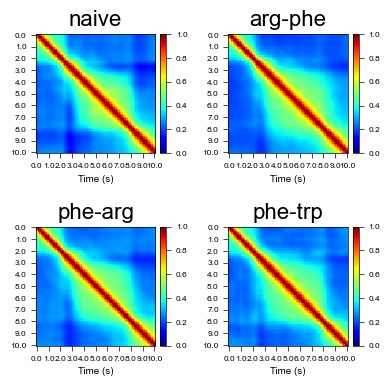

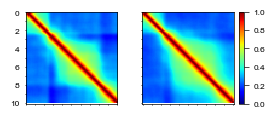

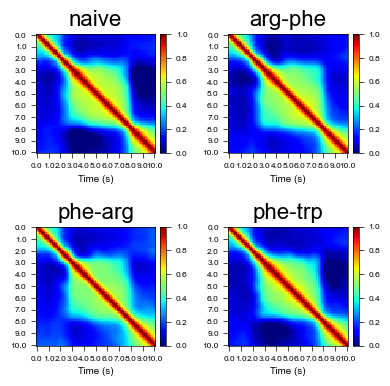

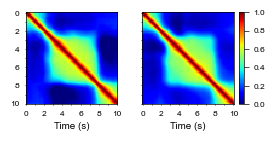

In [61]:

def plot_corr_over_time_for_paper(dsconfig, region, simdf, similarity_method, frame_range, return_data=False):
    # odor = 'Arg'
    # odor_trials = [(odor, 0), (odor, 1), (odor, 2)]
    # simdf = compute_population_multitrial_similarity_over_time(dsconfig, odor_trials, dsconfig.exp_list, bin_size=None, similarity_method=similarity_method)

    plot_trial_similarity_per_cond_parmas = PlotTrialSimilarityPerCondParams(
        row_height=2,
        col_width=2,
        colorbar_fontsize=6,
        plot_params=PlotTrialSimilarityParams(
                                    clim=(0, 1),
                                    cmap='jet',
                                    color_norm=None,
                                    frame_rate=dsconfig.frame_rate,
                                    label_fontsize=7,
                                    tick_fontsize=6,
                                    )
    )
    fig_per_cond, axs, avg_mats, conditions = plot_matrix_per_condition(simdf, conditions=dsconfig.conditions, frame_range=frame_range, params=plot_trial_similarity_per_cond_parmas, return_data=True)

    import copy
    from matplotlib.ticker import MultipleLocator

    def adjust_fig_per_cond(fig_per_cond, tick_fontsize=6, figsize=(1.5, 1.5)):
        fig_per_cond_copy = copy.deepcopy(fig_per_cond)
        ax = fig_per_cond_copy.get_axes()
        # Remove title for ax[0] and ax[1]
        ax[0].set_title('')
        ax[1].set_title('')

        #ax[0].set_ylabel('Time (s)', fontsize=7)

        def set_ticks(ax):
            ytick_labels = ax.get_yticklabels()
            # ytick labels float to int
            ytick_labels = [int(float(label.get_text())) for label in ytick_labels]
            ax.set_yticklabels(ytick_labels, fontsize=tick_fontsize)

            # Only keep every second y tick label
            ytick_labels = ax.get_yticklabels()
            for i, label in enumerate(ytick_labels):
                if i % 2 == 1:
                    label.set_text('')
            ax.set_yticklabels(ytick_labels, fontsize=tick_fontsize)

            # Adjust y and x ticks to have shorter length
            
            ax.tick_params(axis='both', which='both', length=1)

            # Do the same for x ticks
            xtick_labels = ax.get_xticklabels()
            xtick_labels = [int(float(label.get_text())) for label in xtick_labels]
            ax.set_xticklabels(xtick_labels, fontsize=tick_fontsize)
            # Only keep every second x tick label
            xtick_labels = ax.get_xticklabels()
            for i, label in enumerate(xtick_labels):
                if i % 2 == 1:
                    label.set_text('')
            ax.set_xticklabels(xtick_labels, fontsize=tick_fontsize)
            return ax
        set_ticks(ax[0])
        set_ticks(ax[1])

        # Remove y label for ax[0]
        ax[0].set_ylabel('')
        # Remove y tick labels for ax[1]
        ax[1].set_yticklabels([])

        # # Delete colorbar on the first axes
        fig = fig_per_cond_copy
        # Keep arg-phe
        fig.delaxes(fig.axes[2])
        fig.delaxes(fig.axes[5])
        fig.delaxes(fig.axes[2])
        fig.delaxes(fig.axes[4])
        fig.delaxes(fig.axes[2])

        # Make the gap between the two axes smaller
        # Set the size of the figure
        fig_per_cond_copy.set_size_inches(figsize)
        fig_per_cond_copy.tight_layout()
        return fig_per_cond_copy

    fig_per_cond_copy = adjust_fig_per_cond(fig_per_cond, tick_fontsize=6, figsize=(2.85, 2.85))
    if region == 'Dp':
        for ax in fig_per_cond_copy.get_axes():
            # Remove x label and x ticks labels
            ax.set_xlabel('')
            ax.set_xticklabels([])
            
    dataset_name = 'juvenile'
    from os.path import join as pjoin
    from catrace.for_paper import save_figure_for_paper
    paper_fig_root_dir = '../../figures_for_paper'
    dataset_name = 'juvenile'
    paper_fig_dir = pjoin(paper_fig_root_dir, dataset_name)
    save_figure_for_paper(fig_per_cond_copy, f'{dataset_name}_trial_simmat_{similarity_method}_per_cond_{region}', paper_fig_dir)
    if return_data:
        return avg_mats, conditions

avg_mats_dict = {}
conditions_dict = {}
for dsconfig, region in zip(dsconfigs, regions):
    simdf = simdf_dict[region]
    avg_mats, conditions = plot_corr_over_time_for_paper(dsconfig, region, simdf, similarity_method, frame_range, return_data=True)
    avg_mats_dict[region] = avg_mats
    conditions_dict[region] = conditions

In [62]:
import os
import pandas as pd

# Save result data to CSV
figure_data_dir = os.path.join('../../publish_dataset/Hu_Temiz_et_al_dataset', 'figure_data')
os.makedirs(figure_data_dir, exist_ok=True)
save_dir = os.path.join(figure_data_dir, 'extended_figure03')
os.makedirs(save_dir, exist_ok=True)


for region in ['Dp', 'OB']:
    avg_mats = avg_mats_dict[region]
    # concatenate the avg_mats for conditions
    avg_mats_concat = pd.concat(avg_mats.values(), keys=avg_mats.keys(), names=['condition', 'time'])
    avg_mats_concat

    # rename level time to frame in index
    avg_mats_concat = avg_mats_concat.rename_axis(index={'time': 'frame'})
    # Compute time
    time_vec = avg_mats_concat.index.get_level_values('frame') / dp_dsconfig.frame_rate - 2.3
    # Add time_vec into index level
    avg_mats_concat = avg_mats_concat.set_index(pd.Index(time_vec, name='time'), append=True)
    avg_mats_concat = avg_mats_concat.reorder_levels(['condition', 'time', 'frame'])

    time_vec_column = avg_mats_concat.columns / dp_dsconfig.frame_rate - 2.3
    # Append time_vec_column into columns level
    avg_mats_concat.columns = pd.MultiIndex.from_arrays([avg_mats_concat.columns, time_vec_column], names=['frame', 'time'])

    avg_mats_concat
    avg_mats_concat.to_csv(os.path.join(save_dir, f'extended_figure03d_correlation_{region}.csv'))

2021-07-15-DpOBEM-N2_Dp None
2021-07-16-DpOBEM-N3_Dp None
2021-12-10-DpOBEM-N4_Dp None
2021-12-31-DpOBEM-N7_Dp None
2022-02-13-DpOBEM-N10_Dp None
2022-02-20-DpOBEM-N11_Dp None
2021-02-05-DpOBEM-JH9_Dp None
2021-03-18-DpOBEM-JH10_Dp None
2021-03-19-DpOBEM-JH10_Dp None
2021-04-02-DpOBEM-JH11_Dp None
2021-04-03-DpOBEM-JH11_Dp None
2021-05-01-DpOBEM-JH13_Dp None
2021-05-22-DpOBEM-JH14_Dp None
2021-09-15-DpOBEM-JH20_Dp None
2021-09-17-DpOBEM-JH20_Dp None
2021-09-18-DpOBEM-JH20_Dp None
2021-07-30-DpOBEM-JH17_Dp None
2021-07-31-DpOBEM-JH17_Dp None
2021-09-02-DpOBEM-JH18_Dp None
2021-09-03-DpOBEM-JH18_Dp None
2021-09-04-DpOBEM-JH18_Dp None
2021-09-29-DpOBEM-JH21_Dp None
2021-10-01-DpOBEM-JH21_Dp None
2021-10-02-DpOBEM-JH21_Dp None
2021-10-14-DpOBEM-JH22_Dp None
2021-11-10-DpOBEM-JH23_Dp None
2021-11-11-DpOBEM-JH23_Dp None
2021-11-14-DpOBEM-JH23_Dp None
2021-11-24-DpOBEM-JH24_Dp None
2021-11-27-DpOBEM-JH24_Dp None
2021-11-26-DpOBEM-JH24_Dp None
2021-07-15-DpOBEM-N2_Dp None
2021-07-16-DpOBEM-N3_

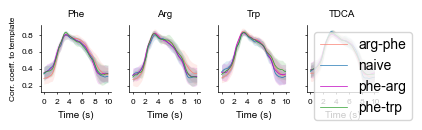

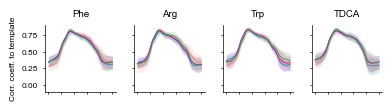

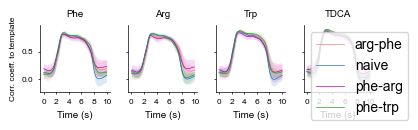

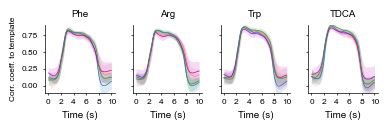

In [63]:

import copy
dataset_name = 'juvenile'
from catrace.for_paper import save_figure_for_paper
paper_fig_dir = '../../../figures_for_paper'
def plot_corr_over_time_slicing_for_paper(dsconfig, region, similarity_method):
    odors = ['Phe', 'Arg', 'Trp', 'TDCA']


    def compute_and_plot_similarity_over_time_to_template(odor_trials, sim_params):
        simtempdf = compute_population_multitrial_similarity_over_time_to_template(dsconfig, odor_trials, dsconfig.exp_list, sim_params)
        colors = {'naive': 'tab:blue', 
                'arg-phe': 'salmon',
                'phe-arg': 'm',
                'phe-trp': 'tab:green'}

        fig = plot_slicing_per_condition(simtempdf, metric=similarity_method, colors=colors, frame_range=frame_range, frame_rate=dsconfig.frame_rate)
        ax = fig.get_axes()[0]
        # Set x tick interval to 1 with multilocator
        ax.xaxis.set_major_locator(plt.MultipleLocator(1))
        fig.suptitle(odor_trials)


    import numpy as np
    template_time_ranges = np.array([(2, 7)])#3), (3, 4), (5, 6)])
    frame_rate = 7.5
    template_frame_ranges = template_time_ranges * frame_rate+ 2.3*frame_rate
    template_frame_ranges = template_frame_ranges.astype(int)
    template_frame_ranges
    template_frame_range = template_frame_ranges[0]
    #template_frame_range = (38, 63)

    sim_params = SimToTemplateParams(template_frame_range=template_frame_range,
                                    similarity_method=similarity_method,
                                    bin_size=None)

    # Compute for each odor
    simtempdfs = []
    for odor in odors:
        # compute_and_plot_trial_similarity_mat_and_slicing(dsconfig, odor, similarity_method)
        odor_trials = [(odor, 0), (odor, 1), (odor, 2)]
        simtempdf = compute_population_multitrial_similarity_over_time_to_template(dsconfig, odor_trials, dsconfig.exp_list, sim_params)
        simtempdfs.append(simtempdf)

    # Create a figure with 4 subplots in a row
    # Plot each simtempdf for each odor with shared y axis

    figsize = (4.3, 1.4)
    label_fontsize = 7
    tick_fontsize = 6
    xtick_interval = 2
    linewidth = 0.5
    std_alpha = 0.15
    err_type = 'std'
    fig, axes = plt.subplots(1, 4, sharey=True, figsize=figsize)

    colors = {'naive': 'tab:blue', 
            'arg-phe': 'salmon',
            'phe-arg': 'm',
            'phe-trp': 'tab:green'}

    # Loop through each odor and its corresponding simtempdf
    simdf_slicing_dict_dict = {}
    for i, (odor, simtempdf) in enumerate(zip(odors, simtempdfs)):
        ax = axes[i]
        # Plot the simtempdf on the current axis
        simdf_slicing_dict = plot_slicing_per_condition(simtempdf, metric=similarity_method, colors=colors, 
                                frame_range=frame_range, frame_rate=dsconfig.frame_rate, ax=ax,
                                linewidth=linewidth,
                                std_alpha=std_alpha,
                                err_type=err_type)
        simdf_slicing_dict_dict[odor] = simdf_slicing_dict
        ax.set_title(odor, fontsize=label_fontsize)
        # Set x tick interval to 1 with MultipleLocator
        ax.xaxis.set_major_locator(plt.MultipleLocator(xtick_interval))
        # Set x and y tick label font size
        ax.set_xlabel('Time (s)', fontsize=label_fontsize)
        ax.tick_params(axis='both', which='major', labelsize=tick_fontsize)
        # Despine
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.tick_params(axis='both', which='both', length=1.5)


    # Add a super title for the entire figure
    #fig.suptitle('Similarity Over Time to Template for Each Odor')

    # Set the y label for the first axis
    if similarity_method == 'pattern_correlation':
        metric_label = 'Corr. coeff. to template'
    elif similarity_method == 'cosine':
        metric_label = 'Cosine distance to template'
    else:
        metric_label = similarity_method

    axes[0].set_ylabel(metric_label, fontsize=tick_fontsize)
    # Remove legend for the axis except the last one
    for ax in axes[:-1]:
        ax.get_legend().remove()
    fig.tight_layout()

    fig_slicing_copy = copy.deepcopy(fig)
    axs = fig_slicing_copy.get_axes()
    axs[-1].legend().remove()

    for ax in axs:
        ax.set_ylim(ylim)

        if region == 'Dp':
            for ax in axs:
                ax.set_xlabel('')
                ax.set_xticklabels([])
                
    fig_name = f'{dataset_name}_similarity_over_time_to_template_{similarity_method}_{region}'
    save_figure_for_paper(fig_slicing_copy, fig_name, paper_fig_dir)
    return simdf_slicing_dict_dict


dsconfig = load_dataset_config('../dataset_configs//juvenile_dataset_t7.json')
similarity_method='pattern_correlation'
ylim = (-0.1, 0.9)
# similarity_method='cosine'
# ylim = (0, 1)

simdf_slicing_dict_dict_dp = plot_corr_over_time_slicing_for_paper(dsconfig, 'Dp', similarity_method)
simdf_slicing_dict_dict_ob = plot_corr_over_time_slicing_for_paper(ob_dsconfig, 'OB', similarity_method)

In [64]:
# Save result data to CSV
figure_data_dir = os.path.join('../../publish_dataset/Hu_Temiz_et_al_dataset', 'figure_data')
os.makedirs(figure_data_dir, exist_ok=True)
save_dir = os.path.join(figure_data_dir, 'extended_figure03')
os.makedirs(save_dir, exist_ok=True)


for region in ['Dp', 'OB']:
    if region == 'Dp':
        simdf_slicing_dict_dict = simdf_slicing_dict_dict_dp
    elif region == 'OB':
        simdf_slicing_dict_dict = simdf_slicing_dict_dict_ob
    else:
        raise ValueError(f'Unknown region: {region}')
    # Concatenate dataframes from two layers of the dictionary of dictionay
    simdf_slicing_concat = pd.concat([df for odor_dict in simdf_slicing_dict_dict.values() for df in odor_dict.values()], axis=1)

    # Remove the last level in columns
    simdf_slicing_concat.columns = simdf_slicing_concat.columns.droplevel(-1)
    # Reorder the levels in columns to fish_id, condition, odor, trial
    simdf_slicing_concat = simdf_slicing_concat.reorder_levels(['fish_id', 'condition', 'odor', 'trial'], axis=1)
    simdf_slicing_concat

    # Rename the level time to frame in index
    simdf_slicing_concat = simdf_slicing_concat.rename_axis(index={'time': 'frame'})
    # Compute time vector
    time_vec = simdf_slicing_concat.index / dp_dsconfig.frame_rate - 2.3
    # Add time_vec into index level
    simdf_slicing_concat = simdf_slicing_concat.set_index(pd.Index(time_vec, name='time'), append=True)
    simdf_slicing_concat.to_csv(os.path.join(save_dir, f'extended_figure03e_correlation_to_template_{region}.csv'))